In [3]:
# ============================================================
# QCTrojan-Bench: Dataset Visualization Notebook
# ============================================================
# Notebook:  VIZ_dataset_exploration.ipynb
# Purpose:   Visual exploration of the QCTrojan-Bench dataset.
#            Generates publication-ready figures for the paper
#            and the dataset GitHub repository.
#
# Authors:   Zeeshan Ajmal
#            University of Oulu, Finland
# Version:   QCTrojan-Bench v1.0
# License:   CC BY 4.0
#
# Prerequisites:
#   S1_benign_circuits.ipynb complete
#   S2_tampered_circuits.ipynb complete
# ============================================================
#
# CELL 1 — Imports and Configuration
# ============================================================

import json
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from qiskit import qpy

# ── Publication figure settings ───────────────────────────────
matplotlib.rcParams.update({
    "figure.dpi":        300,
    "font.size":         9,
    "axes.titlesize":    9,
    "axes.labelsize":    8,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   7,
    "font.family":       "serif",
    "text.usetex":       False,
})

# ── Paths ─────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATASET_ROOT = PROJECT_ROOT / "dataset"
BENIGN_DIR   = DATASET_ROOT / "circuits" / "benign"
TAMPERED_DIR = DATASET_ROOT / "circuits" / "tampered"
RESULTS_DIR  = PROJECT_ROOT / "results" / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────
DATASET_VERSION = "v1"
FAMILIES = [
    "deutsch_jozsa",
    "grover",
    "qaoa",
    "vqc",
    "qft",
]
FAMILY_LABELS = {
    "deutsch_jozsa": "Deutsch-Jozsa",
    "grover":        "Grover",
    "qaoa":          "QAOA",
    "vqc":           "VQC",
    "qft":           "QFT",
}
TROJAN_TYPES  = ["static", "triggered"]
INSPECT_IDX   = 0   # circuit index to use for triplet figures
CIRCUIT_STYLE = "clifford"

print("=" * 55)
print("QCTrojan-Bench — Dataset Visualization")
print("=" * 55)
print(f"  Project root : {PROJECT_ROOT}")
print(f"  Output dir   : {RESULTS_DIR}")
print(f"  Families     : {list(FAMILY_LABELS.values())}")
print("Cell 1 complete.")

QCTrojan-Bench — Dataset Visualization
  Project root : C:\Users\zajmal23\OneDrive - University of Oulu and Oamk\quantum_circuits_exp
  Output dir   : C:\Users\zajmal23\OneDrive - University of Oulu and Oamk\quantum_circuits_exp\results\figures
  Families     : ['Deutsch-Jozsa', 'Grover', 'QAOA', 'VQC', 'QFT']
Cell 1 complete.


In [4]:
# ============================================================
# CELL 2 — Load One Circuit Triplet Per Family
# ============================================================
#
# For each family, loads:
#   - one benign circuit (INSPECT_IDX)
#   - its static tampered variant
#   - its triggered tampered variant
#
# Stores everything in a dict for use by later cells.
# ============================================================

triplets = {}

for family in FAMILIES:
    benign_qpy = (
        BENIGN_DIR / family / DATASET_VERSION / "circuits" /
        f"benign_{family}_{DATASET_VERSION}_{INSPECT_IDX:06d}.qpy"
    )
    static_qpy = (
        TAMPERED_DIR / family / DATASET_VERSION /
        "static" / "circuits" /
        f"tampered_{family}_static_{DATASET_VERSION}_{INSPECT_IDX:06d}.qpy"
    )
    triggered_qpy = (
        TAMPERED_DIR / family / DATASET_VERSION /
        "triggered" / "circuits" /
        f"tampered_{family}_triggered_{DATASET_VERSION}_{INSPECT_IDX:06d}.qpy"
    )
    static_meta_path = (
        TAMPERED_DIR / family / DATASET_VERSION /
        "static" / "metadata" /
        f"tampered_{family}_static_{DATASET_VERSION}_{INSPECT_IDX:06d}.json"
    )
    triggered_meta_path = (
        TAMPERED_DIR / family / DATASET_VERSION /
        "triggered" / "metadata" /
        f"tampered_{family}_triggered_{DATASET_VERSION}_{INSPECT_IDX:06d}.json"
    )

    with open(benign_qpy,    "rb") as f: qc_b = qpy.load(f)[0]
    with open(static_qpy,    "rb") as f: qc_s = qpy.load(f)[0]
    with open(triggered_qpy, "rb") as f: qc_t = qpy.load(f)[0]
    with open(static_meta_path)    as f: meta_s = json.load(f)
    with open(triggered_meta_path) as f: meta_t = json.load(f)

    triplets[family] = {
        "benign":    qc_b,
        "static":    qc_s,
        "triggered": qc_t,
        "meta_static":    meta_s,
        "meta_triggered": meta_t,
    }

    print(f"  {FAMILY_LABELS[family]:15s} — "
          f"benign: {qc_b.num_qubits}q depth={qc_b.depth()}  "
          f"static: depth={qc_s.depth()}  "
          f"triggered: depth={qc_t.depth()}")

print("\nCell 2 complete. All triplets loaded.")

  Deutsch-Jozsa   — benign: 6q depth=2  static: depth=5  triggered: depth=3
  Grover          — benign: 11q depth=23  static: depth=25  triggered: depth=23
  QAOA            — benign: 8q depth=16  static: depth=18  triggered: depth=16
  VQC             — benign: 10q depth=25  static: depth=25  triggered: depth=25
  QFT             — benign: 7q depth=13  static: depth=16  triggered: depth=14

Cell 2 complete. All triplets loaded.


In [4]:
pip install pylatexenc

  Using cached pylatexenc-2.10-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


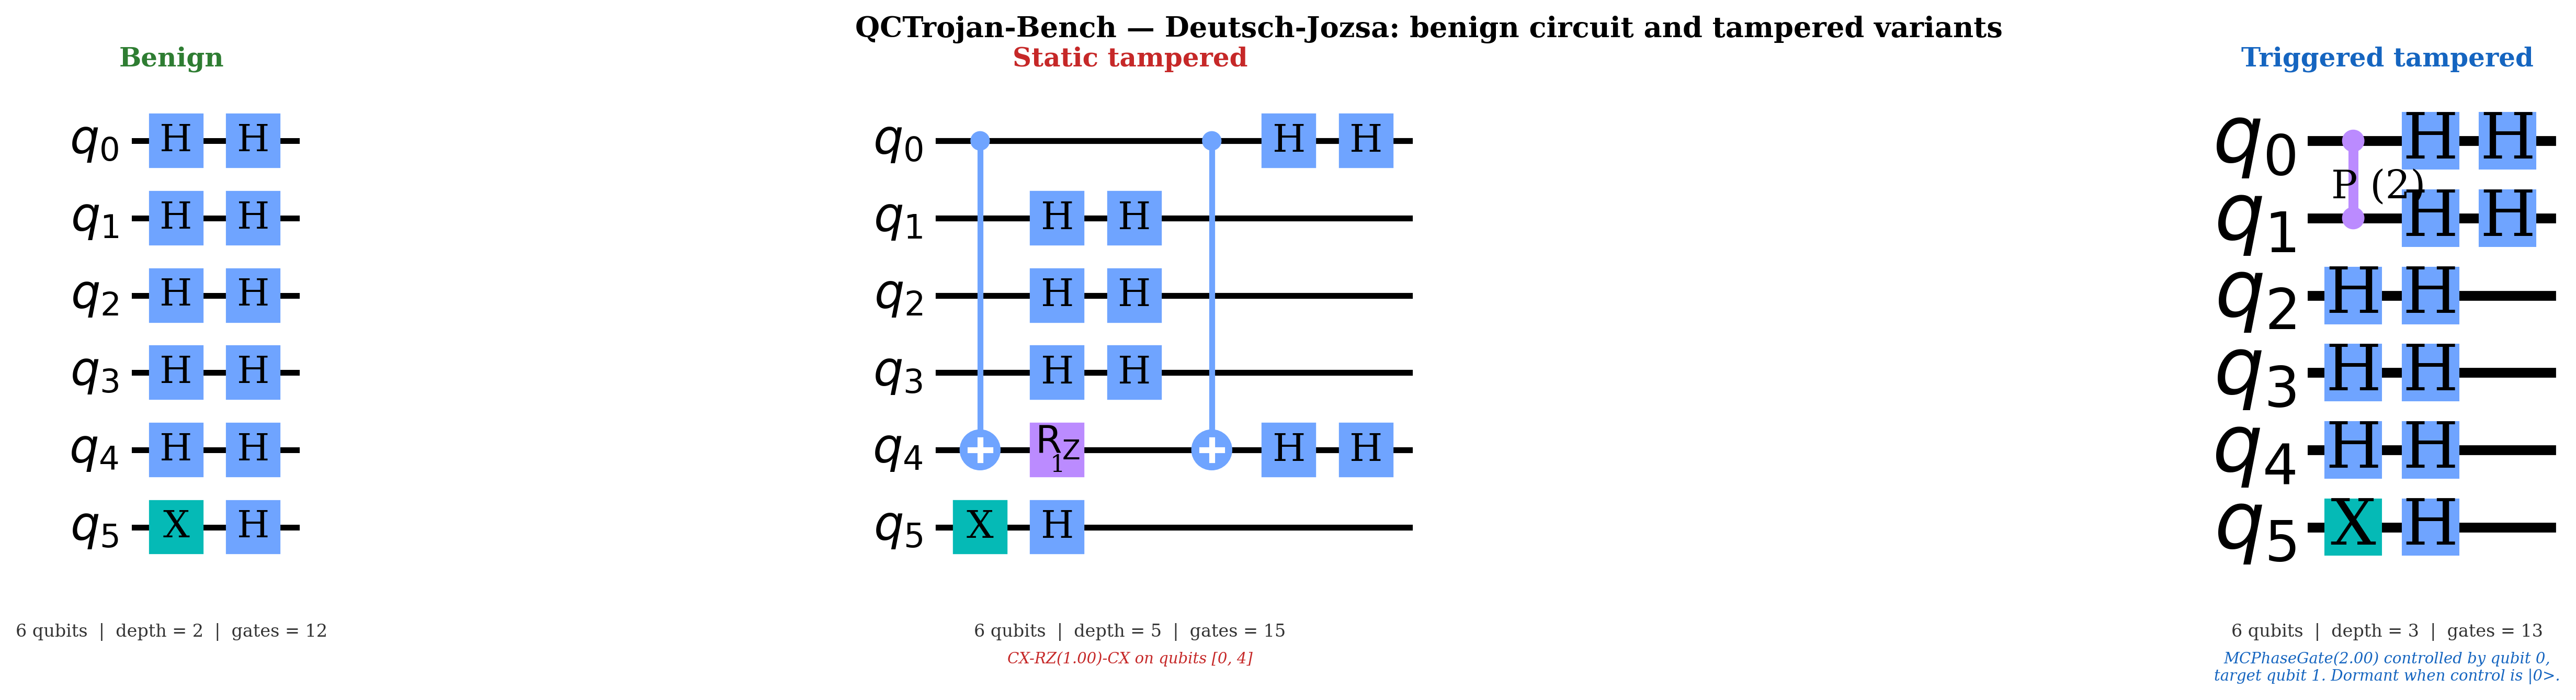

  Saved: fig_triplet_deutsch_jozsa.pdf


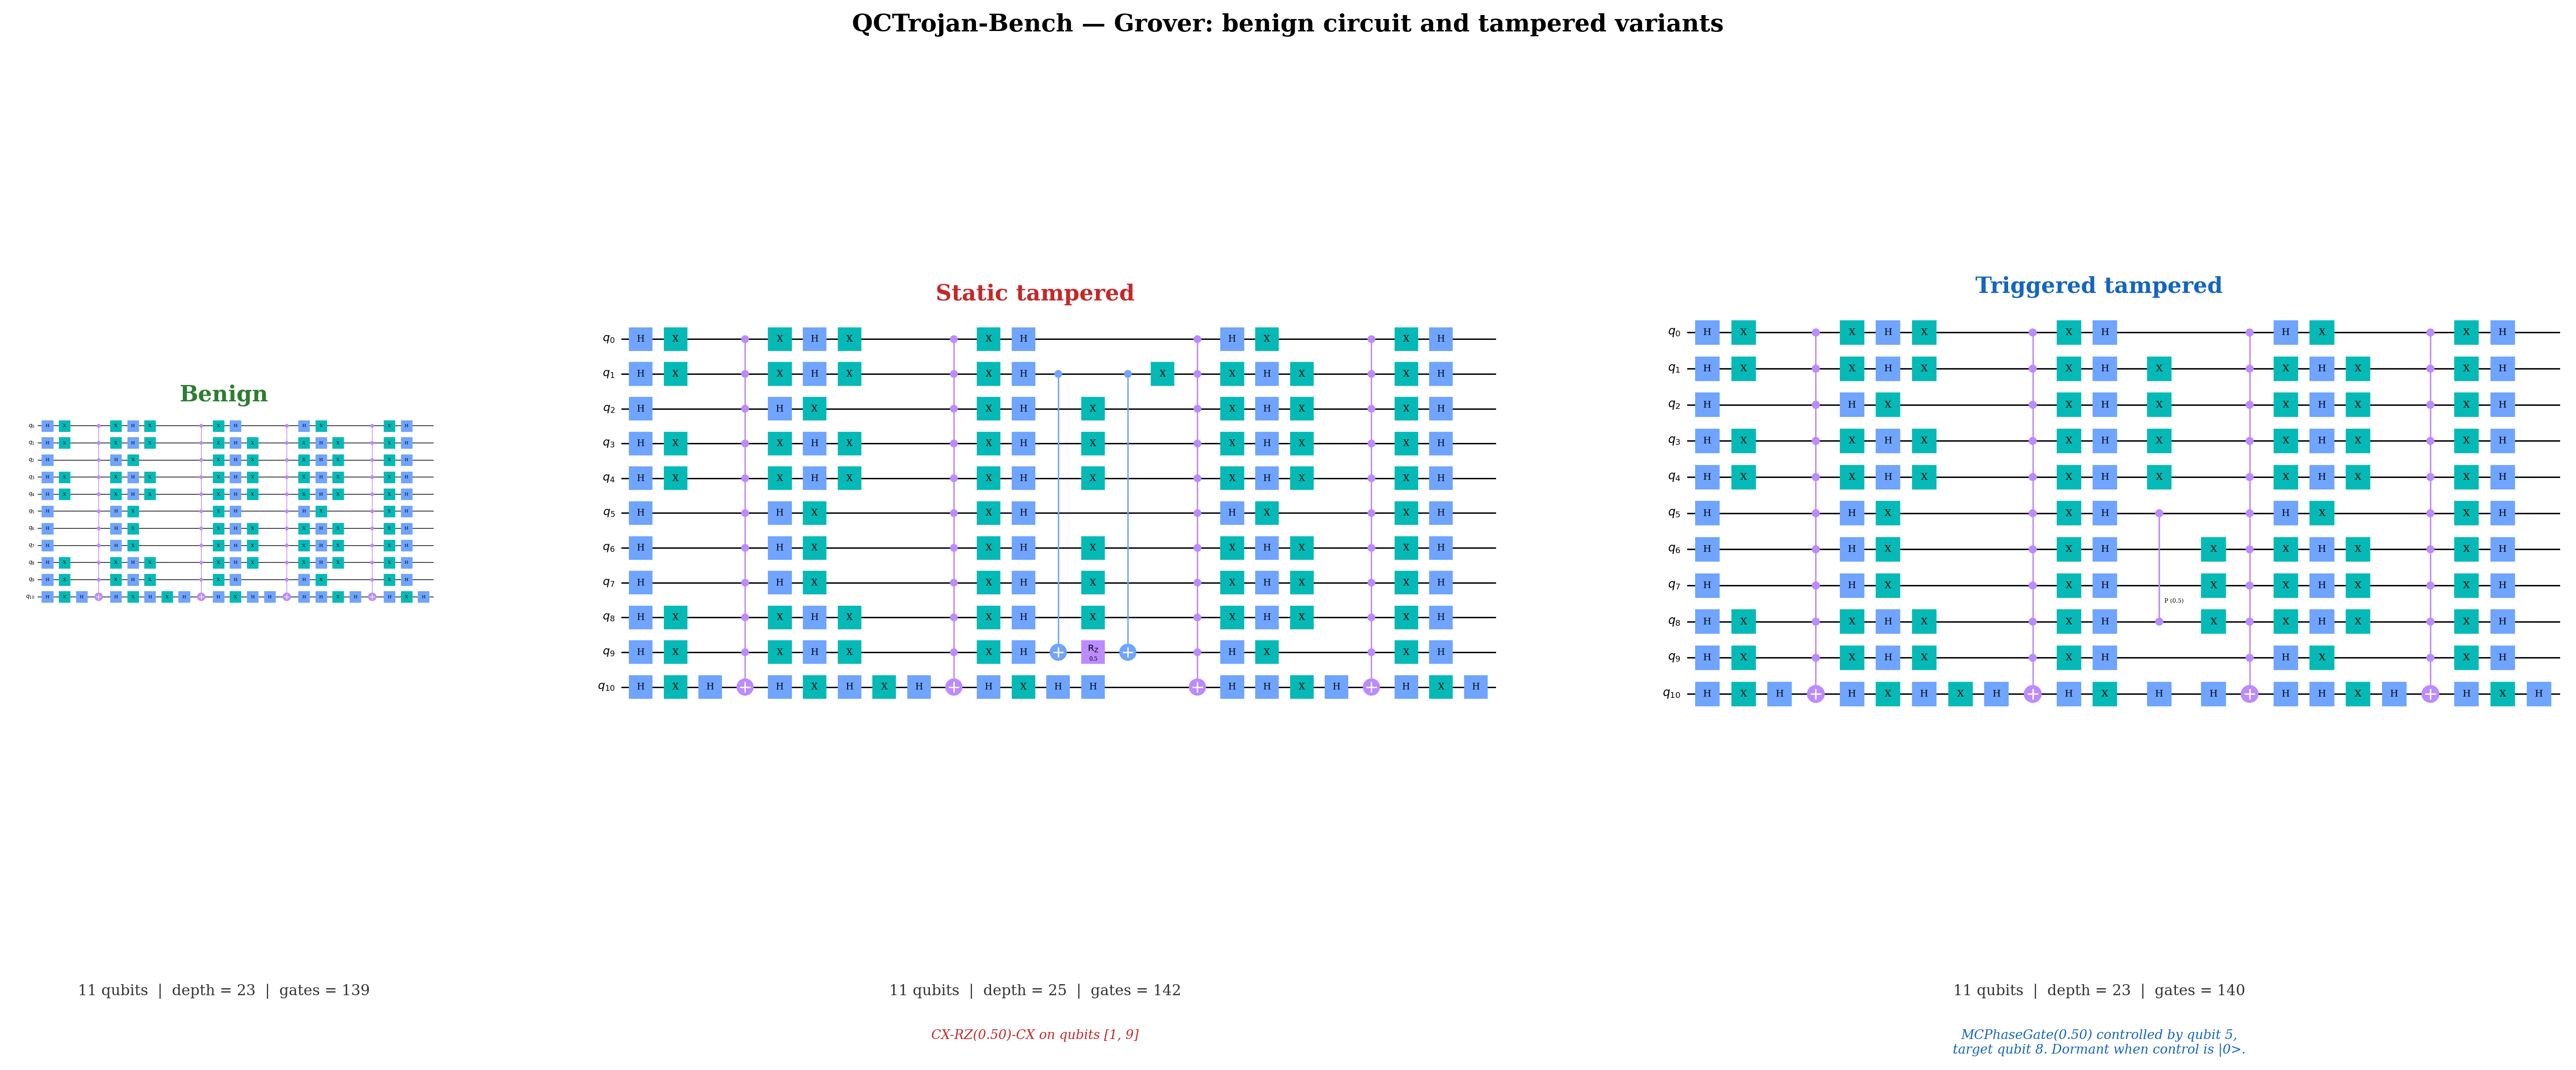

  Saved: fig_triplet_grover.pdf


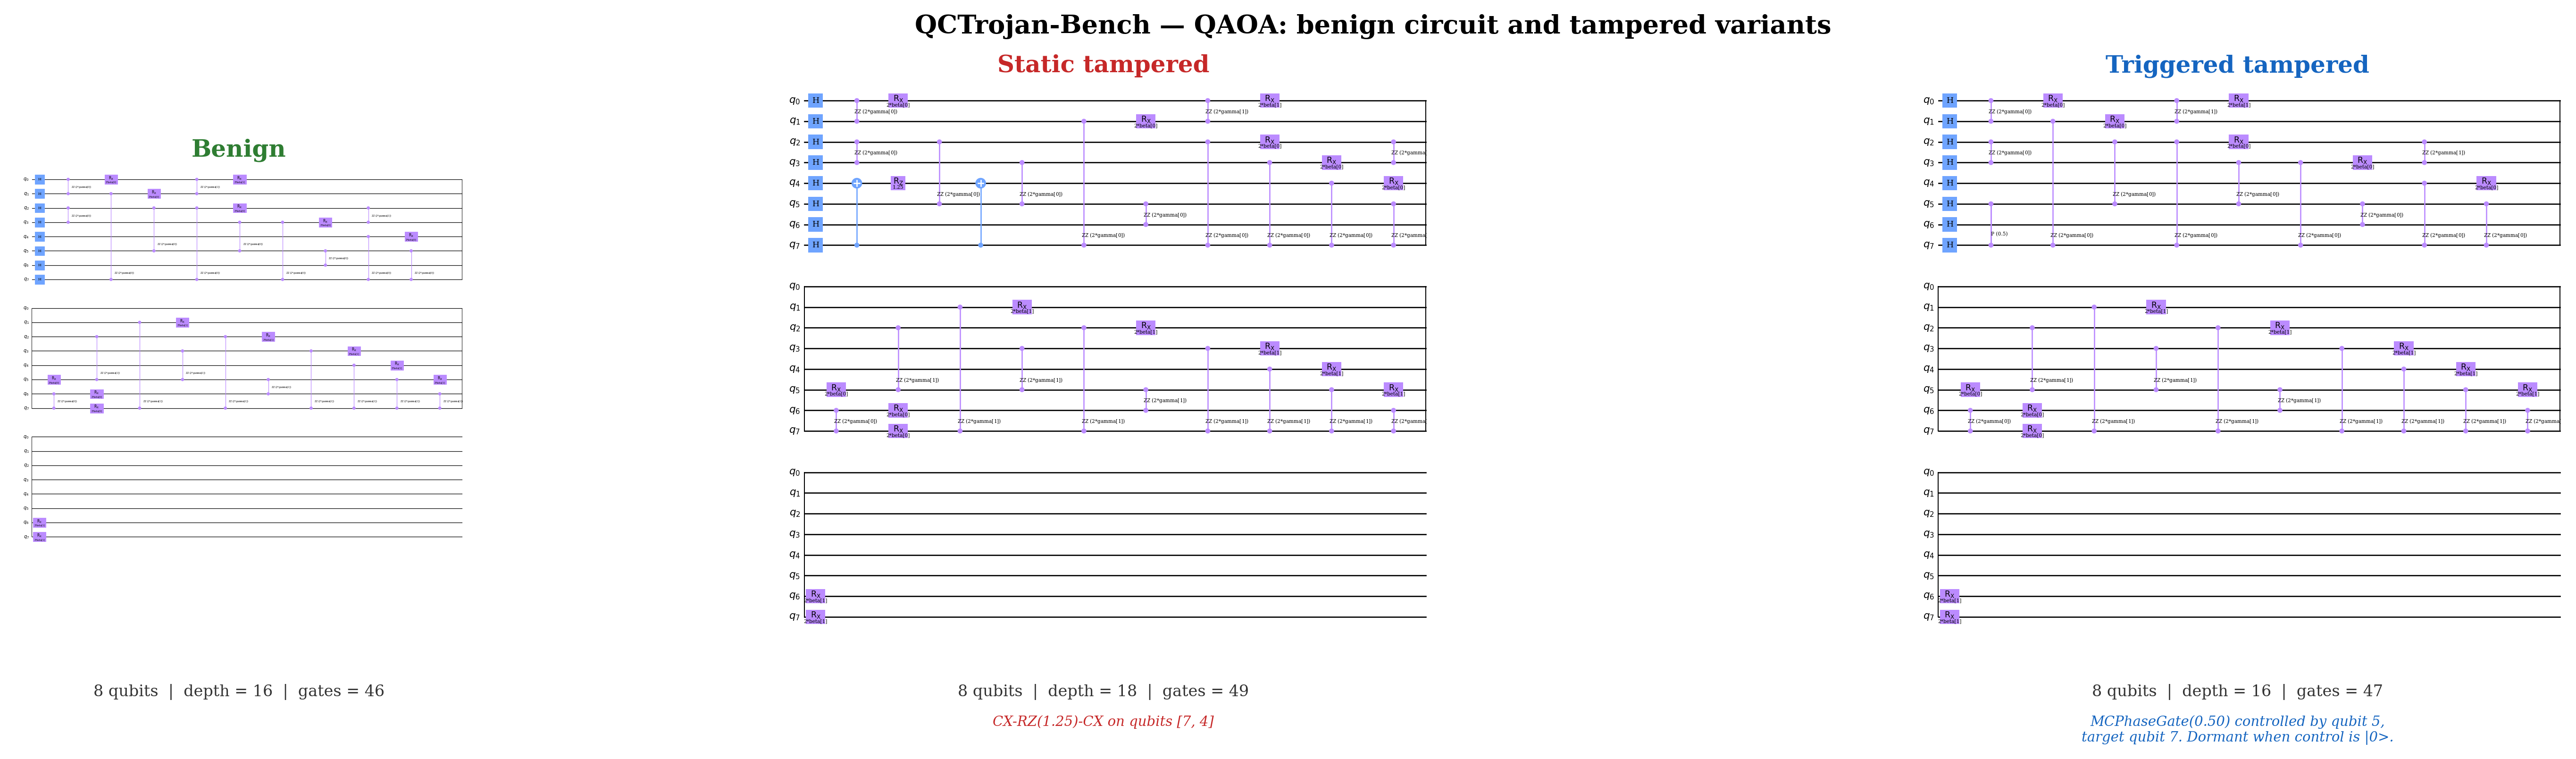

  Saved: fig_triplet_qaoa.pdf


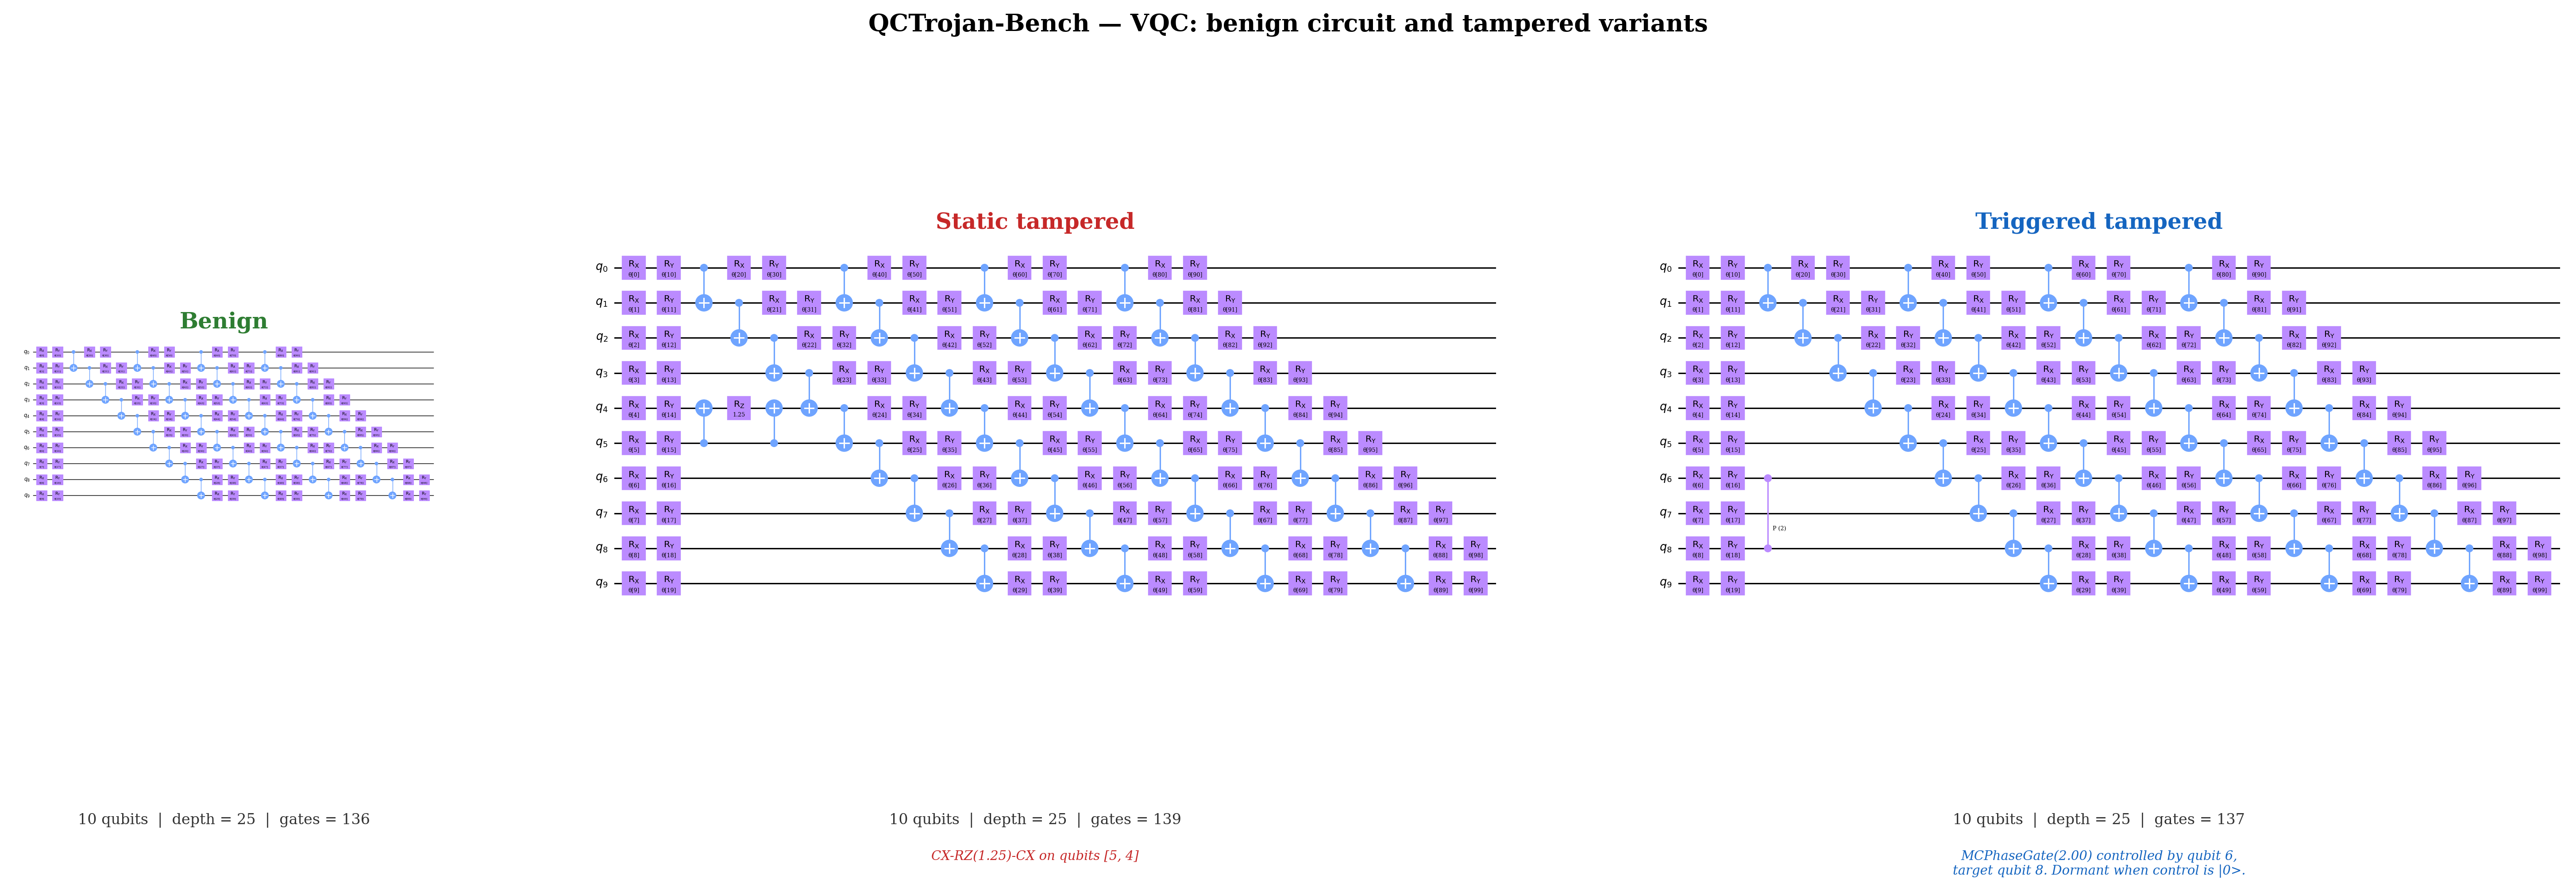

  Saved: fig_triplet_vqc.pdf


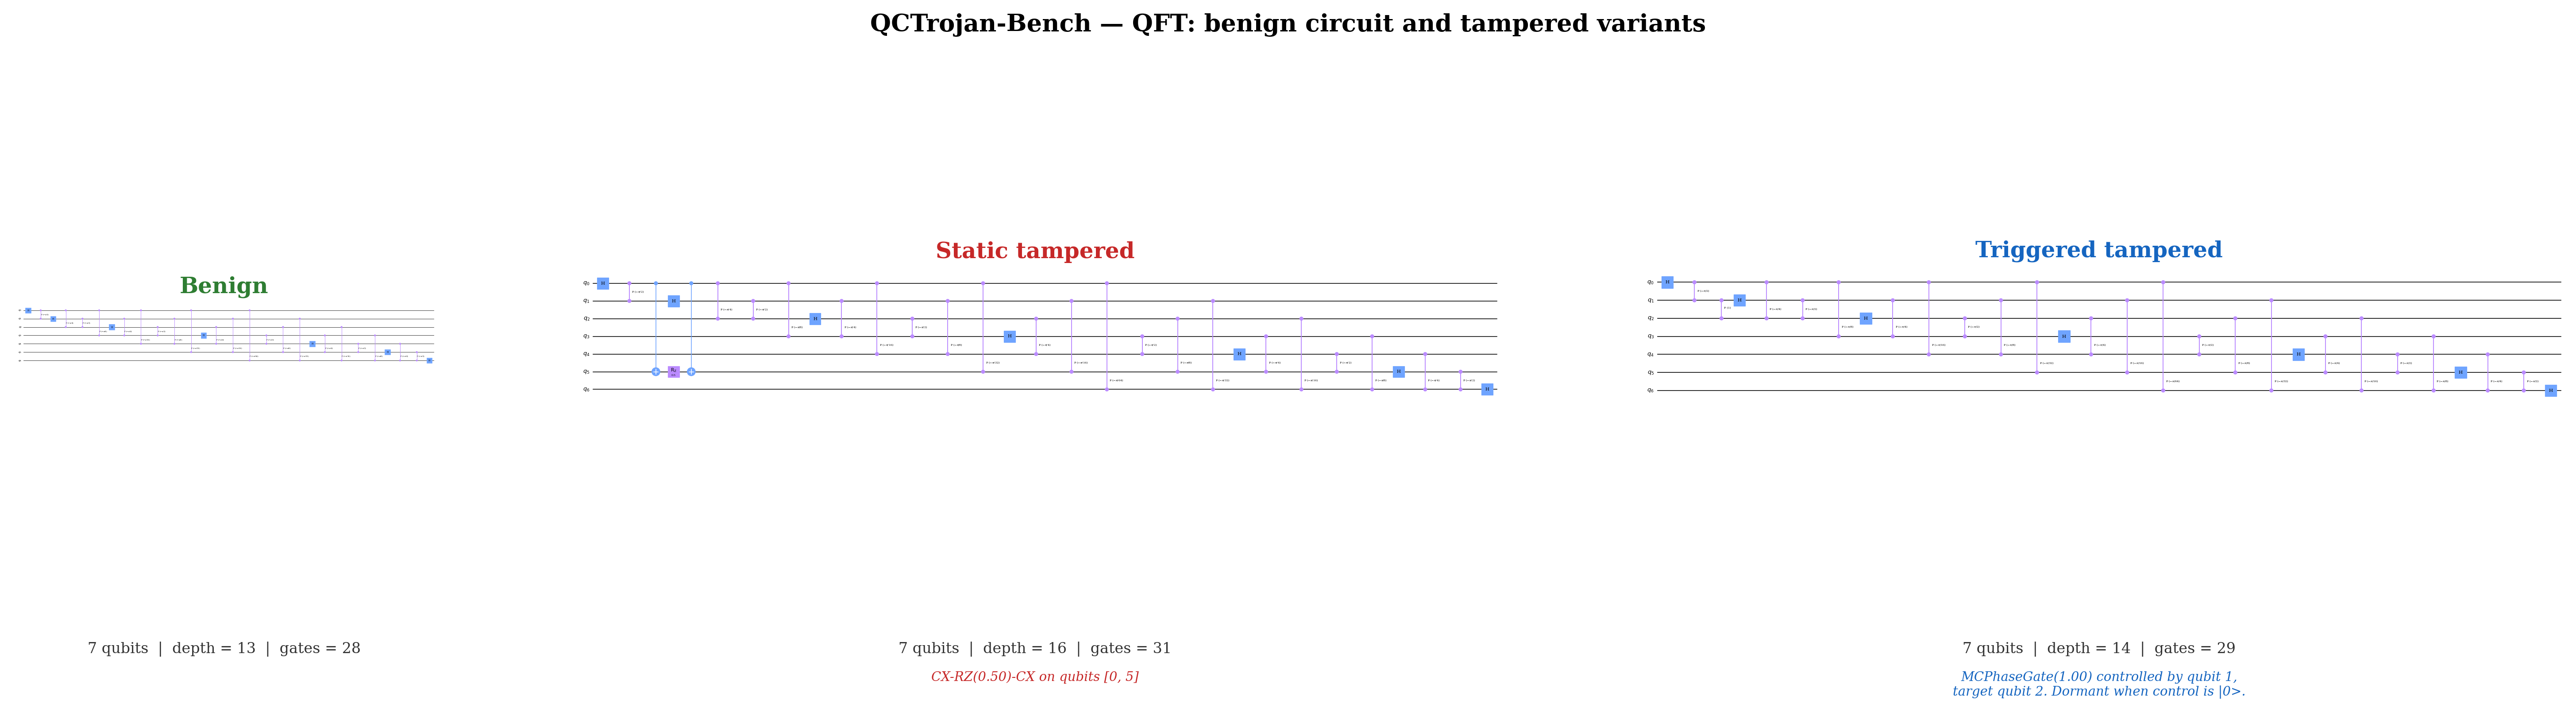

  Saved: fig_triplet_qft.pdf

Cell 3 complete. 5 individual triplet figures saved.


In [11]:
# ============================================================
# CELL 3 (REVISED v4) — Individual Circuit Triplet Per Family
# ============================================================

COL_LABELS = ["Benign", "Static tampered", "Triggered tampered"]
COL_COLORS = ["#2E7D32", "#C62828", "#1565C0"]


def figure_height_for_family(family):
    n = triplets[family]["benign"].num_qubits
    if n <= 4:  return 3.5
    if n <= 6:  return 4.5
    if n <= 8:  return 5.5
    if n <= 10: return 7.0
    if n <= 12: return 8.5
    return 10.0


def fold_for_circuit(qc):
    if qc.num_qubits <= 6:
        return -1
    if len(qc.data) <= 40:
        return -1
    return 30


for family in FAMILIES:
    t        = triplets[family]
    circuits = [t["benign"], t["static"], t["triggered"]]
    metas    = [None, t["meta_static"], t["meta_triggered"]]

    fig_h = figure_height_for_family(family)

    # Unequal column widths — benign is narrow, tampered are wider
    fig, axes = plt.subplots(
        1, 3,
        figsize=(20, fig_h),
        gridspec_kw={"width_ratios": [1, 2.2, 2.2]},
    )

    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.88,
        bottom=0.18,
        wspace=0.18,
    )

    for ax, qc, meta, col_label, col_color in zip(
        axes, circuits, metas, COL_LABELS, COL_COLORS
    ):
        fold = fold_for_circuit(qc)

        qc.draw(
            output="mpl",
            ax=ax,
            style=CIRCUIT_STYLE,
            fold=fold,
            plot_barriers=False,
        )

        # Column title
        ax.set_title(
            col_label,
            fontsize=12,
            fontweight="bold",
            color=col_color,
            pad=6,
            loc="center",
        )

        # Stats line in figure coordinates below axis
        stats_line = (
            f"{qc.num_qubits} qubits  |  "
            f"depth = {qc.depth()}  |  "
            f"gates = {len(qc.data)}"
        )

        pos = ax.get_position()
        cx  = pos.x0 + pos.width / 2

        fig.text(
            cx, 0.11,
            stats_line,
            fontsize=8,
            ha="center",
            va="top",
            color="#333333",
            transform=fig.transFigure,
        )

        if meta:
            desc = meta["payload_description"]
            if len(desc) > 60:
                mid      = len(desc) // 2
                split_at = desc.rfind(" ", 0, mid)
                if split_at > 0:
                    desc = (desc[:split_at] + "\n"
                            + desc[split_at + 1:])

            fig.text(
                cx, 0.07,
                desc,
                fontsize=7,
                ha="center",
                va="top",
                color=col_color,
                style="italic",
                transform=fig.transFigure,
            )

        # Coloured border
        for spine in ax.spines.values():
            spine.set_edgecolor(col_color)
            spine.set_linewidth(1.8)

    # Figure title
    fig.suptitle(
        f"QCTrojan-Bench — {FAMILY_LABELS[family]}: "
        f"benign circuit and tampered variants",
        fontsize=13,
        fontweight="bold",
        y=0.97,
    )

    # Save
    pdf_path = RESULTS_DIR / f"fig_triplet_{family}.pdf"
    png_path = RESULTS_DIR / f"fig_triplet_{family}.png"
    fig.savefig(pdf_path, format="pdf",
                bbox_inches="tight", dpi=300)
    fig.savefig(png_path, format="png",
                bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"  Saved: fig_triplet_{family}.pdf")

print("\nCell 3 complete. 5 individual triplet figures saved.")

Computing depth and gate count statistics...
(Loading all circuits — this takes ~1-2 minutes)
  Deutsch-Jozsa   loaded
  Grover          loaded
  QAOA            loaded
  VQC             loaded
  QFT             loaded
Statistics computed.


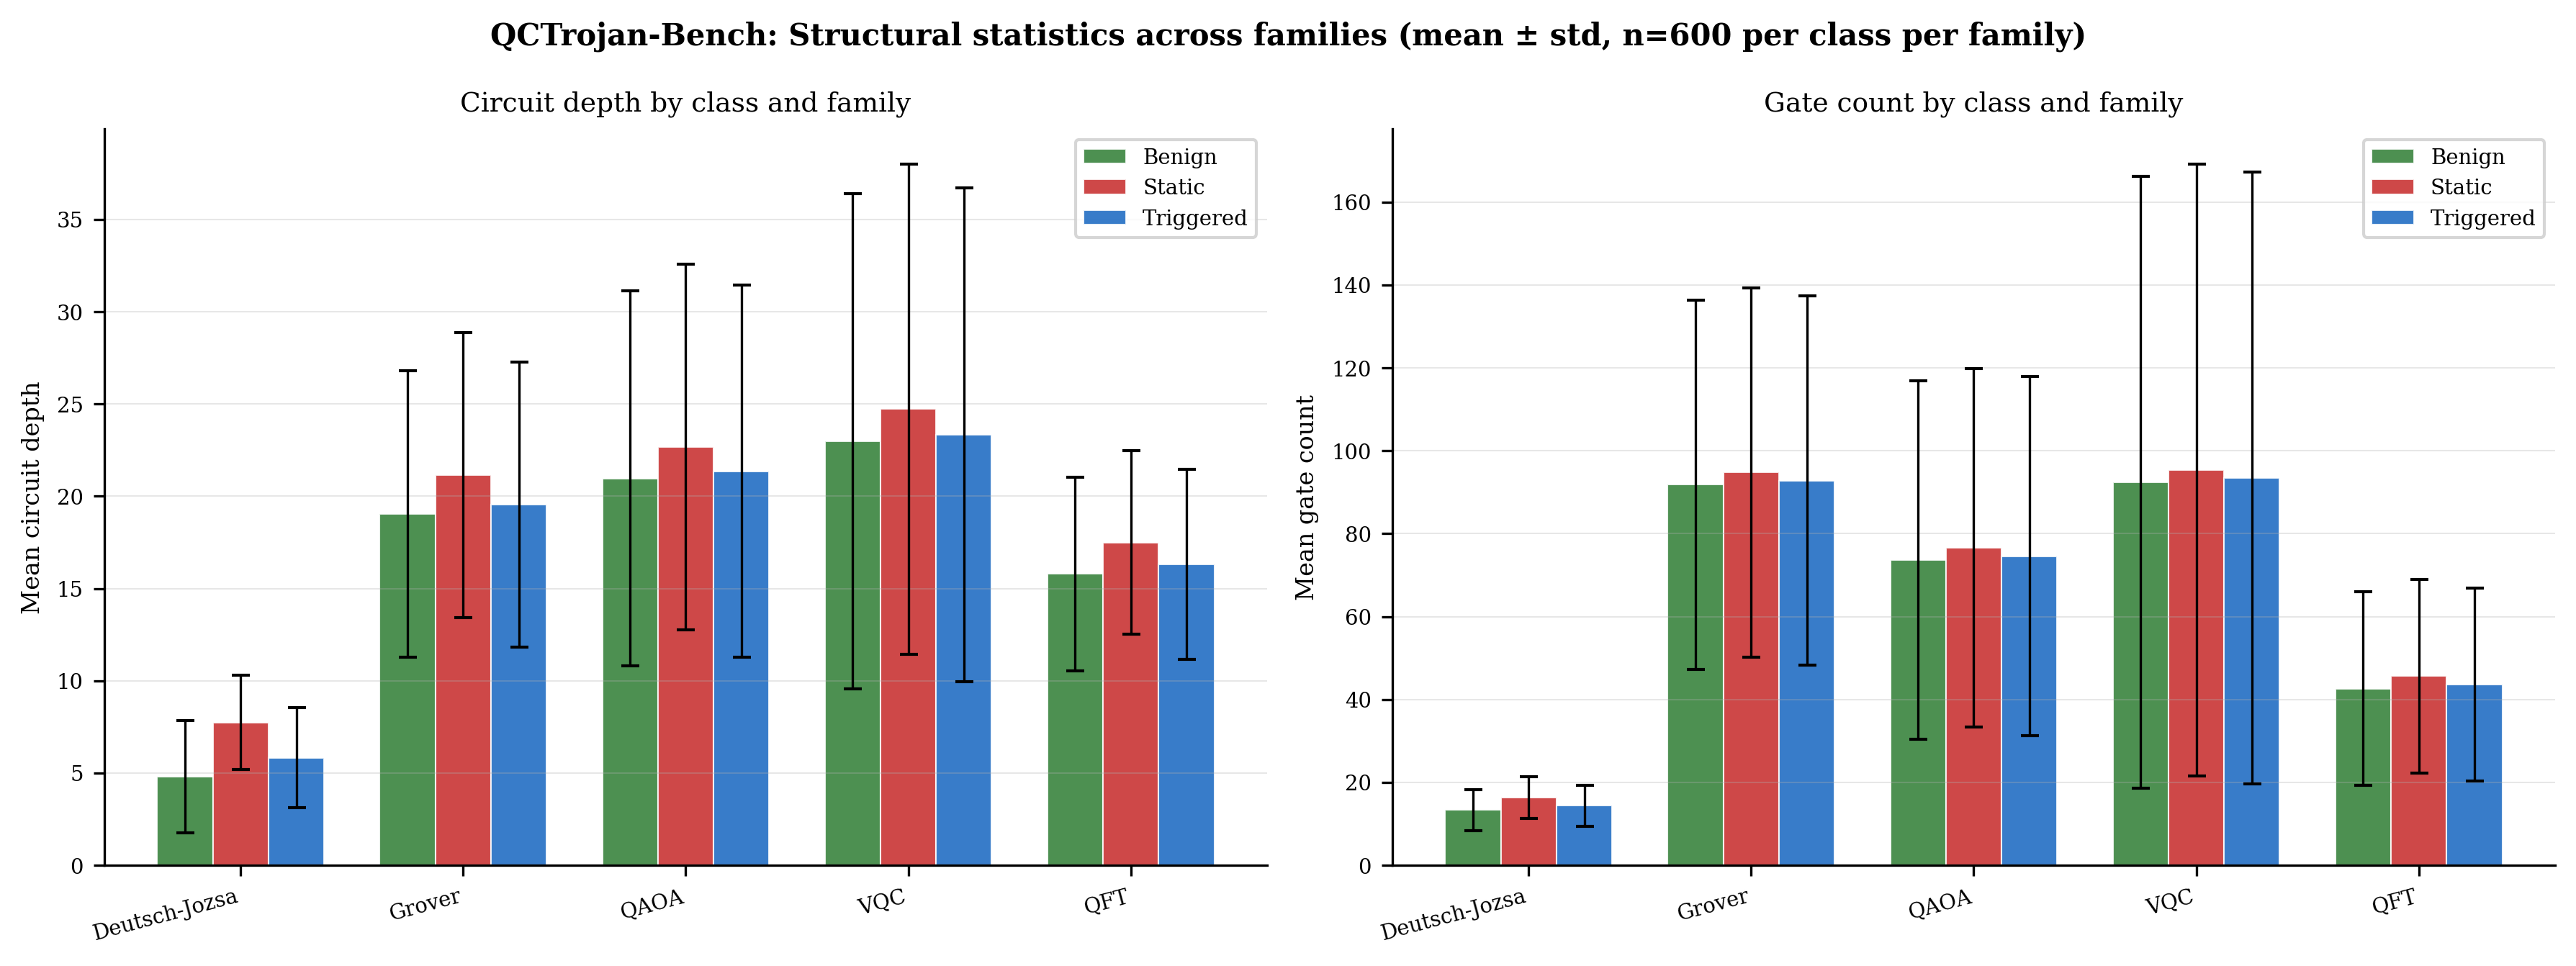

Saved: C:\Users\zajmal23\OneDrive - University of Oulu and Oamk\quantum_circuits_exp\results\figures\fig_depth_gate_comparison.pdf
Saved: C:\Users\zajmal23\OneDrive - University of Oulu and Oamk\quantum_circuits_exp\results\figures\fig_depth_gate_comparison.png
Cell 4 complete.


In [12]:
# ============================================================
# CELL 4 — Depth and Gate Count Comparison Bar Chart
# ============================================================
#
# For each family, shows side-by-side bars for:
#   - mean depth: benign vs static vs triggered
#   - mean gate count: benign vs static vs triggered
#
# Computed over all 600 circuits per family, not just index 0.
# This gives an honest statistical picture for the paper.
# ============================================================

print("Computing depth and gate count statistics...")
print("(Loading all circuits — this takes ~1-2 minutes)")

stats = {
    family: {
        "benign":    {"depths": [], "gates": []},
        "static":    {"depths": [], "gates": []},
        "triggered": {"depths": [], "gates": []},
    }
    for family in FAMILIES
}

for family in FAMILIES:
    # Benign
    benign_dir = BENIGN_DIR / family / DATASET_VERSION / "circuits"
    for qpy_file in sorted(benign_dir.glob("*.qpy")):
        with open(qpy_file, "rb") as f:
            qc = qpy.load(f)[0]
        stats[family]["benign"]["depths"].append(qc.depth())
        stats[family]["benign"]["gates"].append(len(qc.data))

    # Tampered
    for trojan_type in TROJAN_TYPES:
        t_dir = (TAMPERED_DIR / family / DATASET_VERSION
                 / trojan_type / "circuits")
        for qpy_file in sorted(t_dir.glob("*.qpy")):
            with open(qpy_file, "rb") as f:
                qc = qpy.load(f)[0]
            stats[family][trojan_type]["depths"].append(qc.depth())
            stats[family][trojan_type]["gates"].append(len(qc.data))

    print(f"  {FAMILY_LABELS[family]:15s} loaded")

print("Statistics computed.")

# ── Plot ──────────────────────────────────────────────────────

x        = np.arange(len(FAMILIES))
width    = 0.25
classes  = ["benign", "static", "triggered"]
colors   = ["#2E7D32", "#C62828", "#1565C0"]
labels   = ["Benign", "Static", "Triggered"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, metric, ylabel in zip(
    axes,
    ["depths", "gates"],
    ["Mean circuit depth", "Mean gate count"],
):
    for i, (cls, color, label) in enumerate(
        zip(classes, colors, labels)
    ):
        means = [
            np.mean(stats[fam][cls][metric])
            for fam in FAMILIES
        ]
        stds = [
            np.std(stats[fam][cls][metric])
            for fam in FAMILIES
        ]
        bars = ax.bar(
            x + (i - 1) * width,
            means,
            width,
            label=label,
            color=color,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.5,
        )
        ax.errorbar(
            x + (i - 1) * width,
            means,
            yerr=stds,
            fmt="none",
            color="black",
            capsize=3,
            linewidth=0.8,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [FAMILY_LABELS[f] for f in FAMILIES],
        rotation=15,
        ha="right",
    )
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_title("Circuit depth by class and family")
axes[1].set_title("Gate count by class and family")

fig.suptitle(
    "QCTrojan-Bench: Structural statistics across families "
    "(mean ± std, n=600 per class per family)",
    fontsize=10,
    fontweight="bold",
)

plt.tight_layout()

pdf_path = RESULTS_DIR / "fig_depth_gate_comparison.pdf"
png_path = RESULTS_DIR / "fig_depth_gate_comparison.png"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight", dpi=300)
fig.savefig(png_path, format="png", bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")
print("Cell 4 complete.")

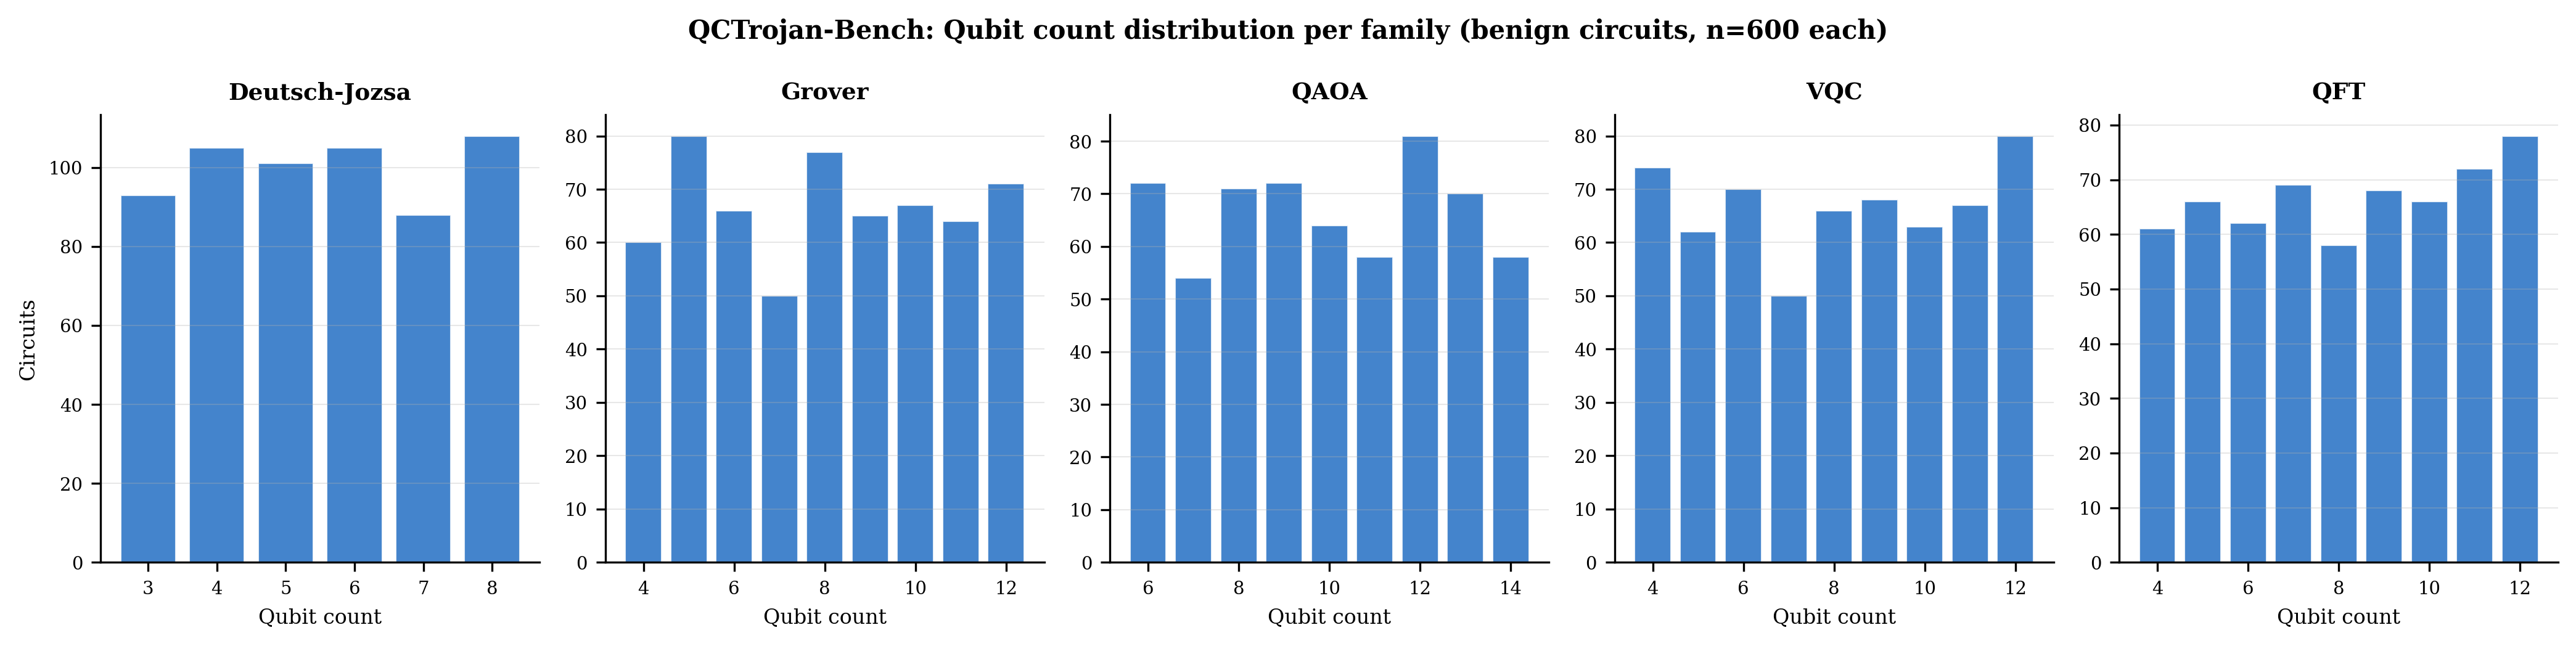

Saved: C:\Users\zajmal23\OneDrive - University of Oulu and Oamk\quantum_circuits_exp\results\figures\fig_qubit_distribution.pdf
Saved: C:\Users\zajmal23\OneDrive - University of Oulu and Oamk\quantum_circuits_exp\results\figures\fig_qubit_distribution.png
Cell 5 complete.


In [13]:
# ============================================================
# CELL 5 — Qubit Distribution Per Family
# ============================================================
#
# Shows the distribution of qubit counts across the 600
# benign circuits per family. Confirms structural diversity.
# ============================================================

fig, axes = plt.subplots(1, N_FAMILIES, figsize=(14, 3.5),
                         sharey=False)

for ax, family in zip(axes, FAMILIES):
    qubit_counts = [
        s for s in
        [qpy.load(open(f, "rb"))[0].num_qubits
         for f in sorted(
             (BENIGN_DIR / family / DATASET_VERSION /
              "circuits").glob("*.qpy")
         )]
    ]

    unique = sorted(set(qubit_counts))
    counts = [qubit_counts.count(u) for u in unique]

    ax.bar(
        unique, counts,
        color="#1565C0",
        alpha=0.8,
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_title(FAMILY_LABELS[family], fontsize=9,
                 fontweight="bold")
    ax.set_xlabel("Qubit count")
    ax.set_ylabel("Circuits" if family == FAMILIES[0] else "")
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "QCTrojan-Bench: Qubit count distribution per family "
    "(benign circuits, n=600 each)",
    fontsize=10,
    fontweight="bold",
)

plt.tight_layout()

pdf_path = RESULTS_DIR / "fig_qubit_distribution.pdf"
png_path = RESULTS_DIR / "fig_qubit_distribution.png"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight", dpi=300)
fig.savefig(png_path, format="png", bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")
print("Cell 5 complete.")